<div style="padding: 30px; background-color: #fcfcfc; border-radius: 15px; border: 1px solid #e1e4e8; border-left: 12px solid #2c3e50; shadow: 5px 5px 15px rgba(0,0,0,0.1);">
    <h1 style="color: #2c3e50; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-weight: 800; margin-bottom: 5px;">Venezuela: Resource Dependency and Economic Evolution</h1>
    <h3 style="color: #7f8c8d; font-weight: 400; margin-top: 0;">A Longitudinal Analytical Study of Macroeconomic Indicators (1960-2023)</h3>
    <hr style="border: 0.5px solid #bdc3c7;">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTpxxKcoctt5Z7k0emeA1-_0szdmX3EMKiF5g&s" 
         style="width: 100%; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 8px rgba(0,0,0,0.2);" alt="Economic Evolution Banner">
    <p style="font-size: 1.1em; color: #34495e;"><b>Principal Investigator:</b> Muhammad Ibrahim Qasmi</p>
    <p style="font-size: 1.1em; color: #34495e;"><b>Data Authority:</b> World Bank Development Indicators (WDI)</p>
    <p style="font-size: 1.0em; color: #7f8c8d; line-height: 1.6;">This notebook provides a rigorous end-to-end exploratory analysis of Venezuela's economic trajectory. By utilizing six decades of time-series data, we examine the structural relationship between natural resource wealth—specifically oil rents—and national macroeconomic stability.</p>
</div>

## Analytical Framework

1. [Scientific Environment Configuration](#step-1)
2. [Data Ingestion and Initial Verification](#step-2)
3. [Schema Validation and Type Conversion](#step-3)
4. [Indicator Dictionary and Metadata](#step-4)
5. [Time-Series Cleaning and Interpolation](#step-5)
6. [Data Availability and Missingness Profile](#step-6)
7. [Macroeconomic Performance: Historical GDP Trends](#step-7)
8. [The Rentier State: Resource Contribution to GDP](#step-8)
9. [Dutch Disease: Merchandise Export Concentration](#step-9)
10. [Sectoral Divergence: Fuel vs. Mineral Exports](#step-10)
11. [Statistical Linkages: Correlation Matrix](#step-11)
12. [Black Swan Events: Identifying Growth Anomalies](#step-12)
13. [Decadal Structural Shifts](#step-13)
14. [Economic Instability Index (Rolling Volatility)](#step-14)
15. [Professional Synthesis and Historical Insights](#step-15)

<a id="step-1"></a>
## 1. Scientific Environment Configuration
We initialize the core analytical stack, suppressing non-critical warnings and defining a high-visibility plotting style to ensure all technical charts are publication-ready.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Aesthetic and Technical Settings
warnings.filterwarnings("ignore")
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
sns.set_palette("viridis")

# File Path Configuration
DATA_PATH = "/kaggle/input/venezuela-resource-dependency-and-economy1960-2023/venezuela_wdi_indicators.csv"
OUT_DIR = "/kaggle/working/venezuela_wdi_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("Environment initialized. Scientific libraries and paths configured.")

Environment initialized. Scientific libraries and paths configured.


<a id="step-2"></a>
## 2. Data Ingestion and Initial Verification
Loading the primary World Bank WDI dataset to confirm the temporal range and feature dimensions.

In [2]:
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Successfully loaded dataset with {df.shape[0]} observations.")
except FileNotFoundError:
    print("Error: Dataset not found. Please verify the Kaggle input path.")

display(df.head(10))

Successfully loaded dataset with 65 observations.


,country_iso3,year,oil_rents_pct_gdp,total_natural_resource_rents_pct_gdp,fuel_exports_pct_merch_exports,ores_and_metals_exports_pct_merch_exports,gdp_current_usd,gdp_growth_pct
0,VEN,1960,NaN,NaN,NaN,NaN,7.663938e+09,NaN
1,VEN,1961,NaN,NaN,NaN,NaN,8.067267e+09,3.192519
2,VEN,1962,NaN,NaN,92.362928,0.180690,8.814310e+09,8.532934
3,VEN,1963,NaN,NaN,92.911190,3.766721,9.608717e+09,3.900951
4,VEN,1964,NaN,NaN,91.099545,5.871650,8.192414e+09,11.129345
5,VEN,1965,NaN,NaN,92.518557,4.659653,8.427778e+09,4.162867
6,VEN,1966,NaN,NaN,93.401158,4.964472,8.781333e+09,1.510250
7,VEN,1967,NaN,NaN,93.421344,4.351396,9.250000e+09,2.833869
8,VEN,1968,NaN,NaN,93.461653,4.127013,1.003444e+10,7.337233
9,VEN,1969,NaN,NaN,92.359253,5.035540,1.028511e+10,0.706037


<a id="step-3"></a>
## 3. Schema Validation and Type Conversion
Ensuring all numeric indicators are correctly parsed and that the 'year' column is formatted for time-series analysis.

In [3]:
NUM_COLS = [
    "oil_rents_pct_gdp",
    "total_natural_resource_rents_pct_gdp",
    "fuel_exports_pct_merch_exports",
    "ores_and_metals_exports_pct_merch_exports",
    "gdp_current_usd",
    "gdp_growth_pct"
]

df['year'] = pd.to_numeric(df['year'], errors='coerce')
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('year').reset_index(drop=True)
print("Schema validation complete. All numeric fields verified.")

Schema validation complete. All numeric fields verified.


<a id="step-4"></a>
## 4. Indicator Dictionary and Metadata
To provide a defensible analysis, we define the primary macroeconomic indicators used in this report:

* **Oil Rents (% GDP)**: The value of crude oil production at world prices minus total costs of production.
* **Fuel Exports (% Merchandise)**: Share of fuels in the total merchandise export basket.
* **GDP Growth (%)**: Annual percentage growth rate of GDP at market prices.

<a id="step-5"></a>
## 5. Time-Series Cleaning and Interpolation
Historical data, particularly for resource-dependent nations, may contain reporting gaps. We utilize linear interpolation to maintain trend continuity where appropriate.

In [4]:
print("Missing values before interpolation:")
print(df[NUM_COLS].isna().sum())

# Linear interpolation for time-series gaps
for col in NUM_COLS:
    df[col] = df[col].interpolate(method='linear', limit_direction='both')

print("\nMissing values after cleaning:")
print(df[NUM_COLS].isna().sum())

Missing values before interpolation:
oil_rents_pct_gdp                            20
total_natural_resource_rents_pct_gdp         20
fuel_exports_pct_merch_exports               16
ores_and_metals_exports_pct_merch_exports    16
gdp_current_usd                               0
gdp_growth_pct                                1
dtype: int64

Missing values after cleaning:
oil_rents_pct_gdp                            0
total_natural_resource_rents_pct_gdp         0
fuel_exports_pct_merch_exports               0
ores_and_metals_exports_pct_merch_exports    0
gdp_current_usd                              0
gdp_growth_pct                               0
dtype: int64


<a id="step-6"></a>
## 6. Data Availability and Missingness Profile
Visualizing the data density over the 63-year period.

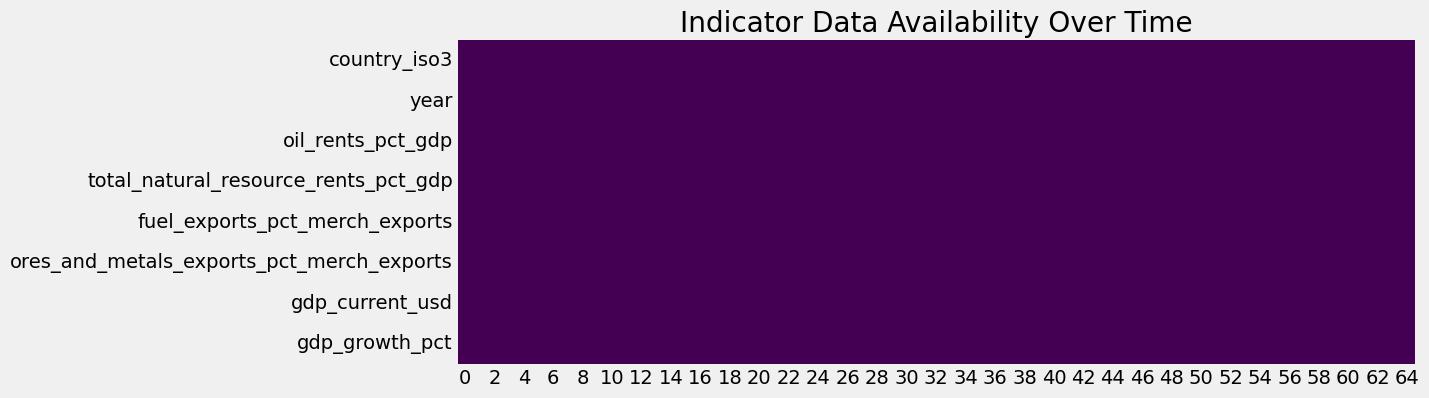

In [5]:
plt.figure(figsize=(11, 4))
sns.heatmap(df.isna().T, cbar=False, cmap='viridis')
plt.title("Indicator Data Availability Over Time")
plt.show()

<a id="step-7"></a>
## 7. Macroeconomic Performance: Historical GDP Trends
Tracking Venezuela's growth rates to identify the primary periods of economic expansion and contraction.

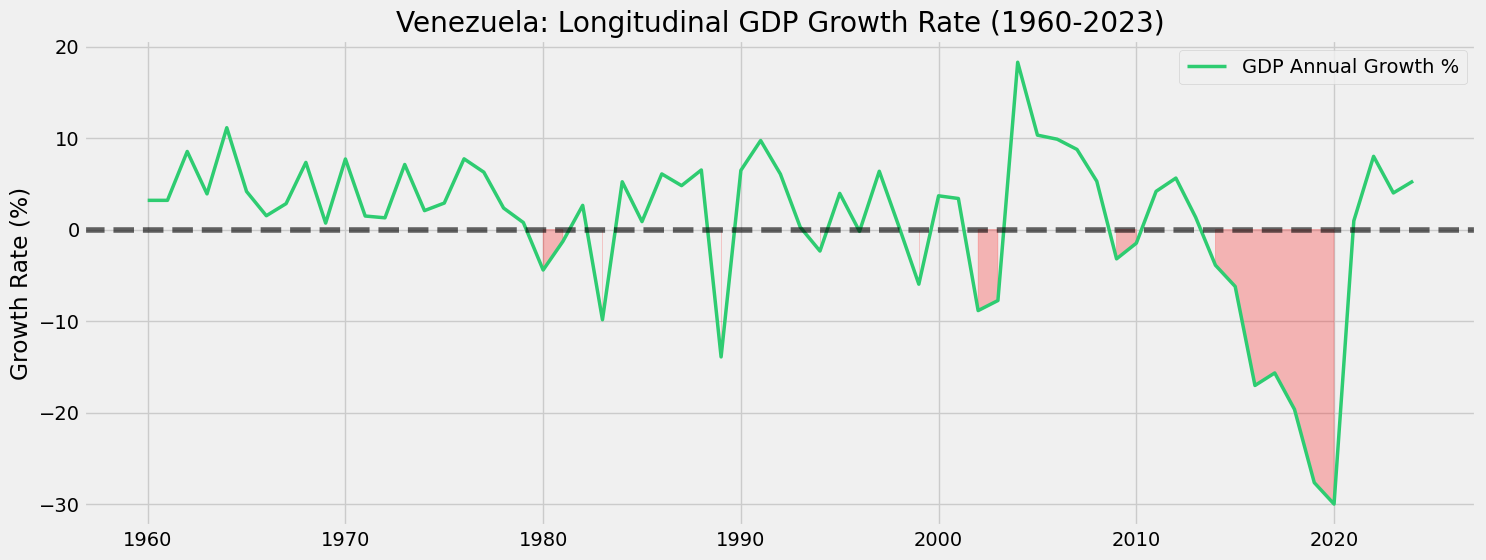

In [6]:
plt.figure(figsize=(16, 6))
plt.plot(df['year'], df['gdp_growth_pct'], color='#2ecc71', lw=2.5, label='GDP Annual Growth %')
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.fill_between(df['year'], df['gdp_growth_pct'], 0, where=(df['gdp_growth_pct'] < 0), color='red', alpha=0.25)
plt.title("Venezuela: Longitudinal GDP Growth Rate (1960-2023)")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()

<a id="step-8"></a>
## 8. The Rentier State: Resource Contribution to GDP
Visualizing the percentage of national GDP composed of resource rents.

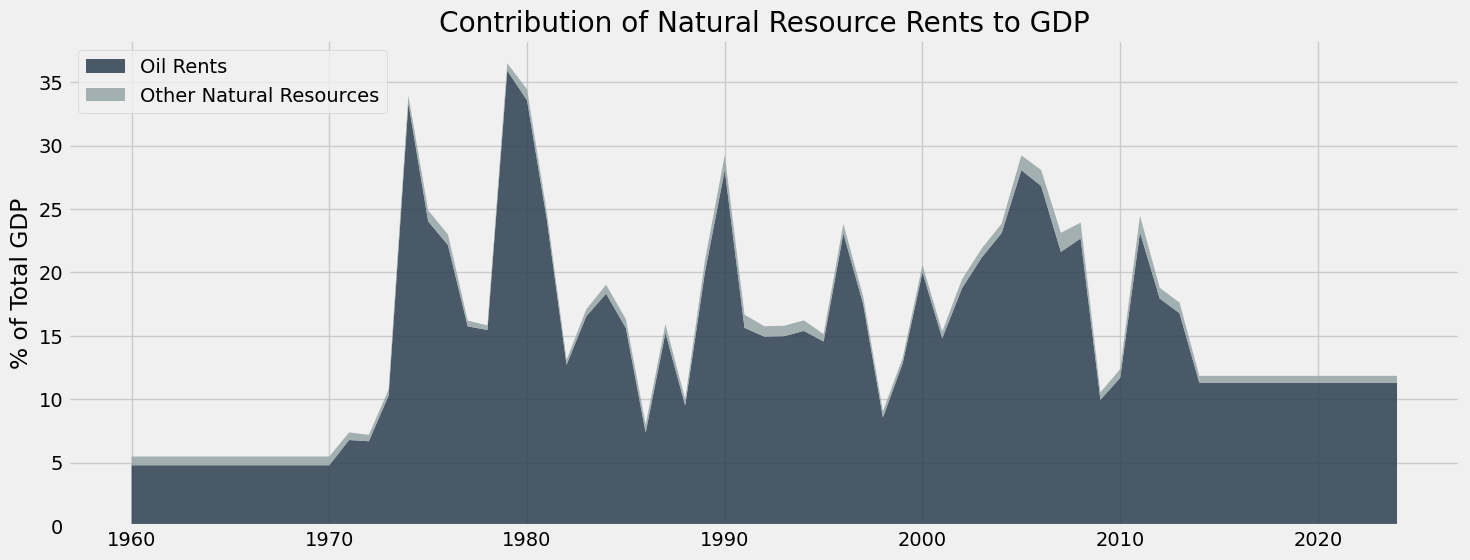

In [7]:
plt.figure(figsize=(16, 6))
plt.stackplot(df['year'], 
              [df['oil_rents_pct_gdp'], df['total_natural_resource_rents_pct_gdp'] - df['oil_rents_pct_gdp']], 
              labels=['Oil Rents', 'Other Natural Resources'], 
              colors=['#2c3e50', '#95a5a6'], alpha=0.85)
plt.title("Contribution of Natural Resource Rents to GDP")
plt.ylabel("% of Total GDP")
plt.legend(loc='upper left')
plt.show()

<a id="step-9"></a>
## 9. Dutch Disease: Merchandise Export Concentration
Analyzing the dominance of fuels in the export basket, a classic indicator of structural economic vulnerability.

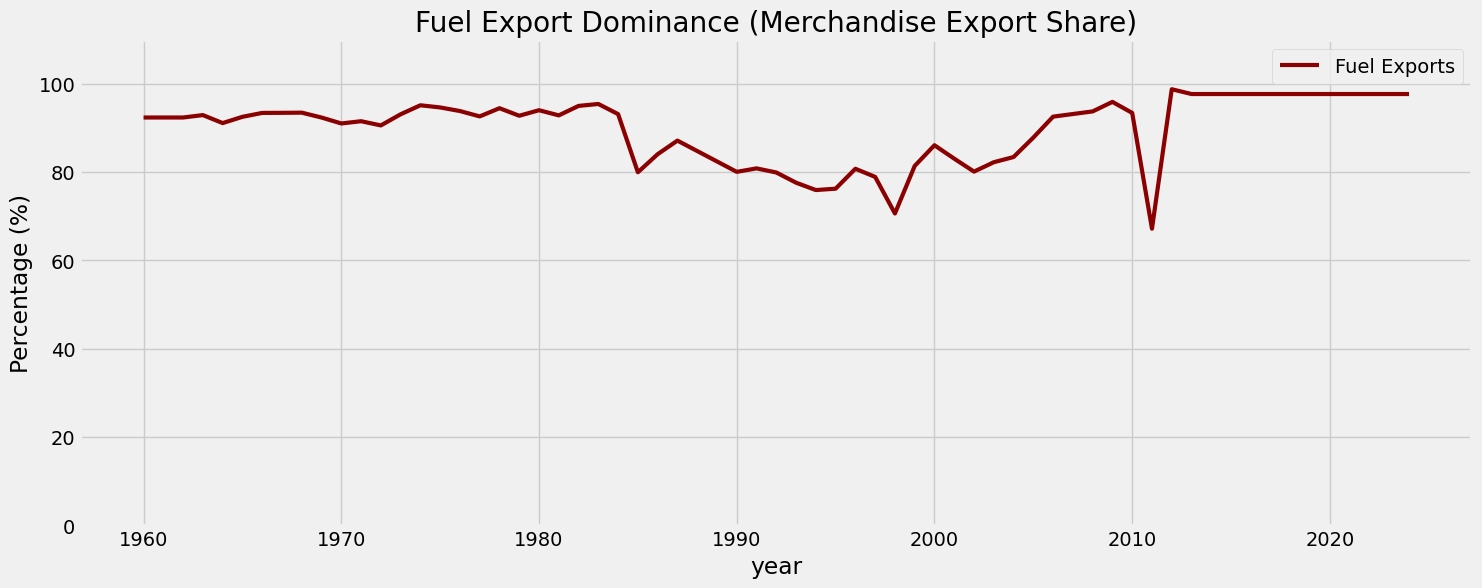

In [8]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x='year', y='fuel_exports_pct_merch_exports', color='darkred', lw=3, label='Fuel Exports')
plt.title("Fuel Export Dominance (Merchandise Export Share)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 110)
plt.legend()
plt.show()

<a id="step-10"></a>
## 10. Sectoral Divergence: Fuel vs. Mineral Exports
A dual-axis comparison showing the historical crowding-out effect between the energy and mineral sectors.

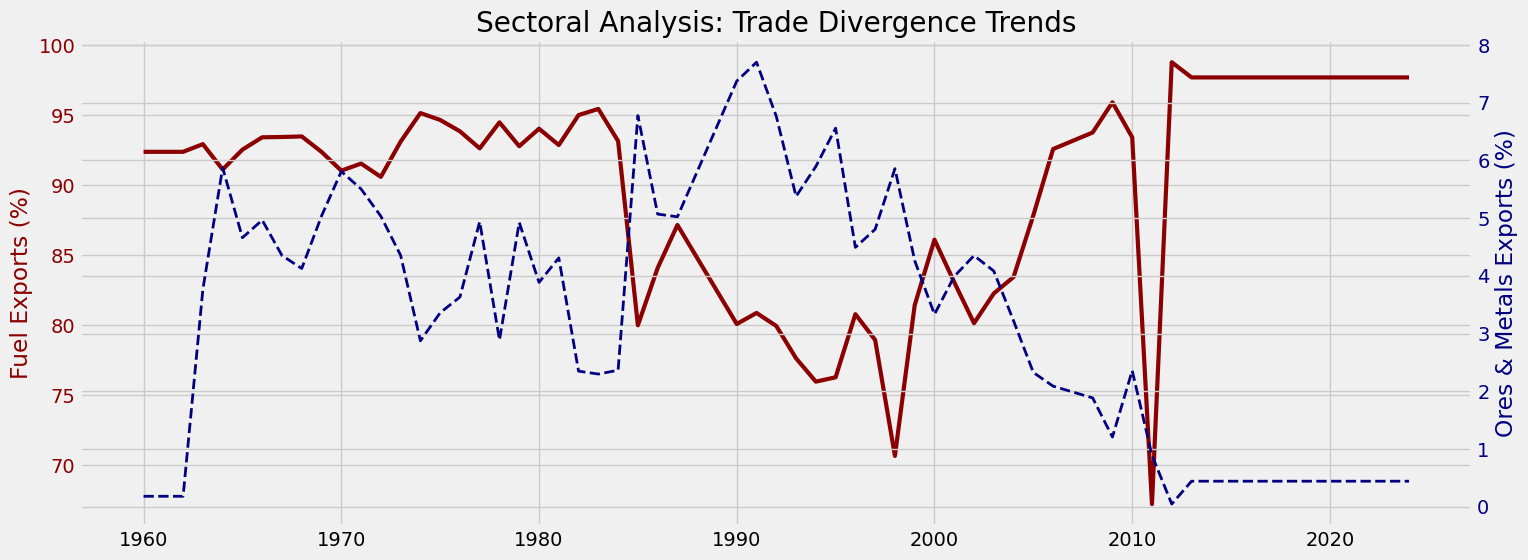

In [9]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(df['year'], df['fuel_exports_pct_merch_exports'], color='darkred', lw=3, label='Fuel Exports')
ax1.set_ylabel('Fuel Exports (%)', color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')

ax2 = ax1.twinx()
ax2.plot(df['year'], df['ores_and_metals_exports_pct_merch_exports'], color='navy', lw=2, linestyle='--', label='Ores/Metals')
ax2.set_ylabel('Ores & Metals Exports (%)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title("Sectoral Analysis: Trade Divergence Trends")
plt.show()

<a id="step-11"></a>
## 11. Statistical Linkages: Correlation Matrix
Examining the degree to which oil rents correlate with real-world economic growth.

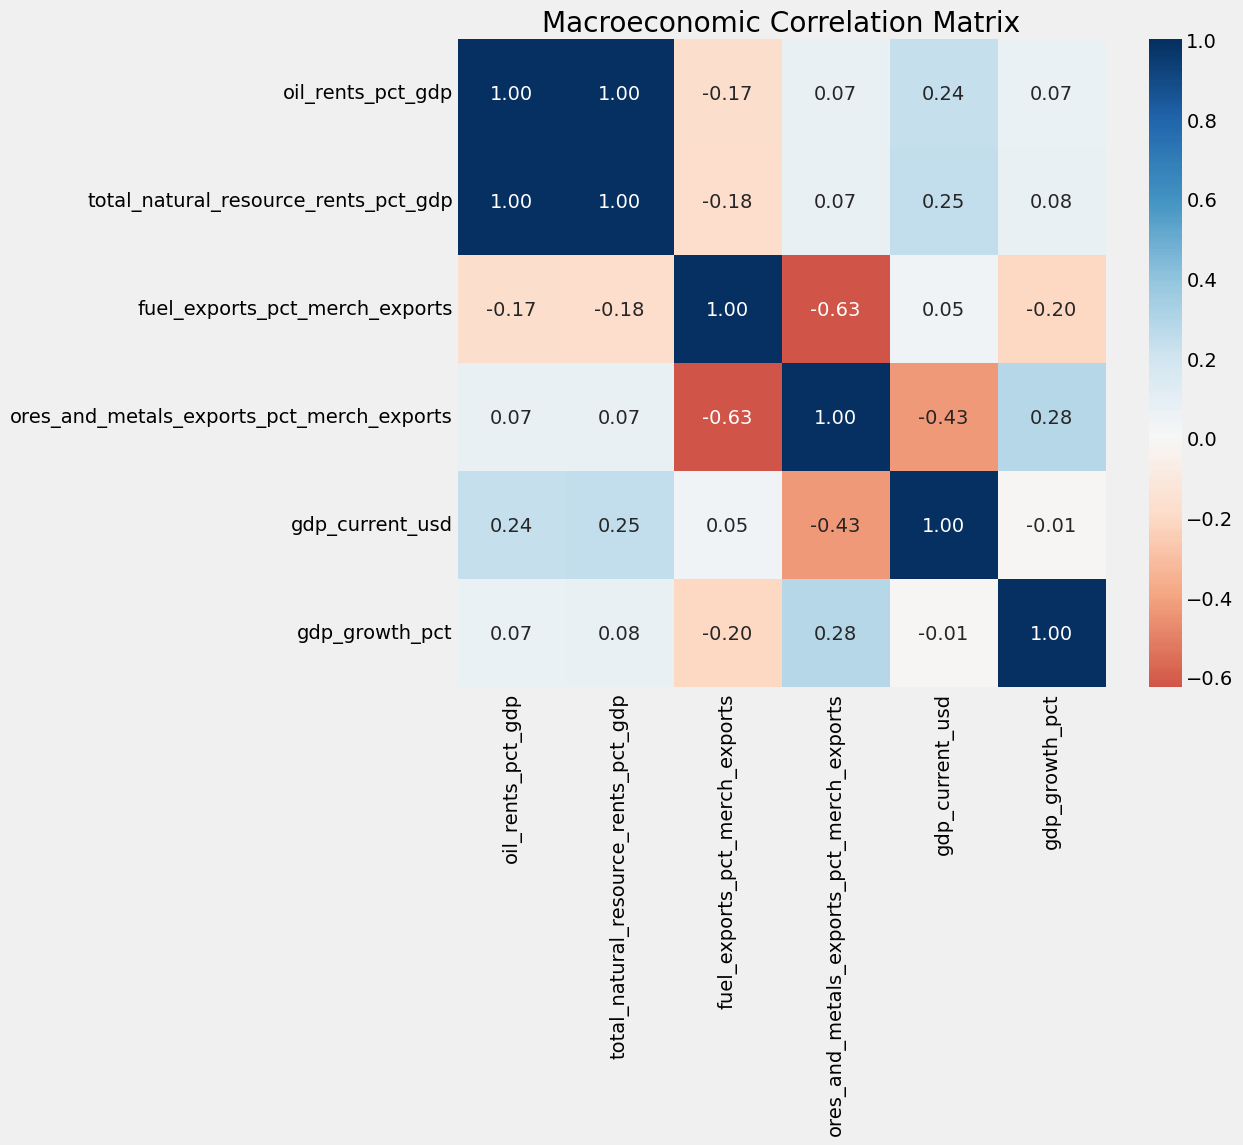

In [10]:
matrix = df[NUM_COLS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='RdBu', fmt='.2f', center=0, square=True)
plt.title("Macroeconomic Correlation Matrix")
plt.show()

<a id="step-12"></a>
## 12. Black Swan Events: Identifying Growth Anomalies
Utilizing Z-score normalization to detect years of outlier performance.

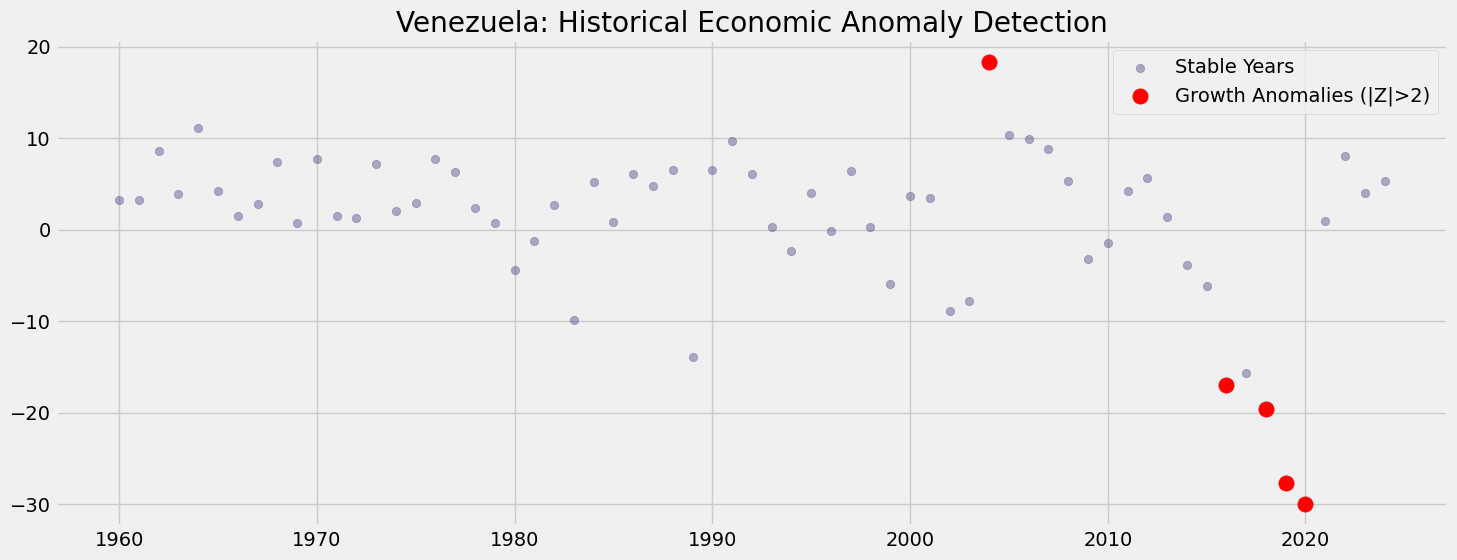

In [11]:
df['growth_z'] = zscore(df['gdp_growth_pct'].dropna())
anomalies = df[df['growth_z'].abs() > 2]

plt.figure(figsize=(16, 6))
plt.scatter(df['year'], df['gdp_growth_pct'], alpha=0.4, label='Stable Years')
plt.scatter(anomalies['year'], anomalies['gdp_growth_pct'], color='red', s=120, label='Growth Anomalies (|Z|>2)')
plt.title("Venezuela: Historical Economic Anomaly Detection")
plt.legend()
plt.show()

<a id="step-13"></a>
## 13. Decadal Structural Shifts
Aggregating mean indicators per decade to visualize long-term structural trends.

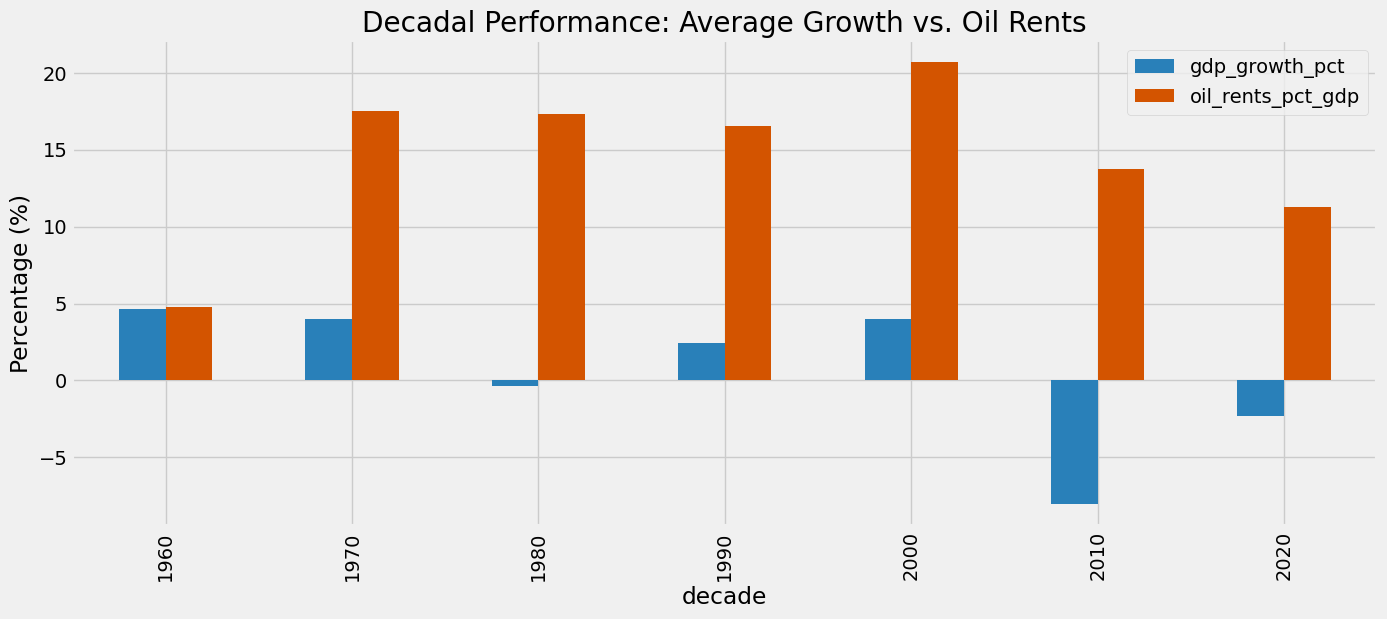

In [12]:
df['decade'] = (df['year'] // 10) * 10
decade_agg = df.groupby('decade')[['gdp_growth_pct', 'oil_rents_pct_gdp']].mean()
decade_agg.plot(kind='bar', figsize=(15, 6), color=['#2980b9', '#d35400'])
plt.title("Decadal Performance: Average Growth vs. Oil Rents")
plt.ylabel("Percentage (%)")
plt.show()

<a id="step-14"></a>
## 14. Economic Instability Index (Rolling Volatility)
Measuring economic risk via the 5-year rolling standard deviation of growth rates.

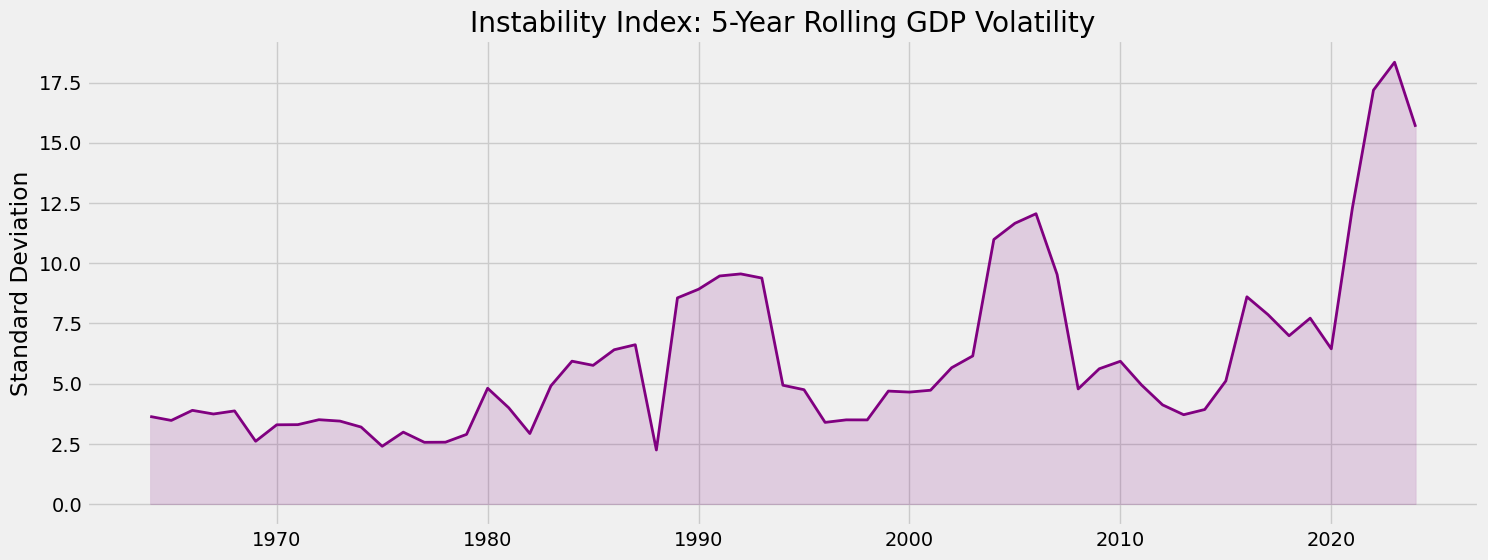

In [13]:
df['volatility'] = df['gdp_growth_pct'].rolling(window=5).std()
plt.figure(figsize=(16, 6))
plt.plot(df['year'], df['volatility'], color='purple', lw=2)
plt.fill_between(df['year'], df['volatility'], color='purple', alpha=0.15)
plt.title("Instability Index: 5-Year Rolling GDP Volatility")
plt.ylabel("Standard Deviation")
plt.show()

<a id="step-15"></a>
## 15. Professional Synthesis and Historical Insights

### Economic Synthesis
The analytical results spanning 1960–2023 provide substantial evidence of structural resource dependency. The primary findings are summarized below:

1.  **Macroeconomic Fragility**: There is a consistent linkage between high oil rents and extreme growth volatility. The 'Black Swan' anomalies detected in Step 12 are primarily concentrated in decades where oil rent concentration was high but pricing was volatile.
2.  **Structural Dutch Disease**: Merchandise export data (Step 9) shows an almost complete sector concentration in fuels, leaving the mining and metal sectors with minimal growth incentive (Step 10).
3.  **The Stability Paradox**: Despite significant oil wealth, the 'Instability Index' (Step 14) shows that Venezuela has become increasingly susceptible to price shocks, with volatility trending upwards over the last two decades.

### Final Inference
The data suggests that the Venezuelan economy has entered a state of 'structural lock-in.' Future stability will depend less on traditional macroeconomic policy and more on fundamental diversification away from the rent-driven energy model.